# Human Activity Recognition using Deep Learning

## Dataset Exploration

This notebook explores the **UCI Human Activity Recognition (HAR) Dataset**.

### Objectives

- Understand the dataset structure
- Load raw inertial sensor signals
- Inspect activity labels
- Explore dataset dimensions
- Visualize sensor signals
- Prepare for preprocessing

## Import Libraries

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

# Better visualization
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

# Display all dataframe columns
pd.set_option("display.max_columns", None)

## Define Dataset Path

In [2]:
DATASET_PATH = Path("../data/UCI HAR Dataset")

TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"

print(DATASET_PATH.resolve())

/home/farhad/workspace/human-activity-recognition/data/UCI HAR Dataset


## Display Dataset Structure

In [3]:
for item in DATASET_PATH.iterdir():
    print(item.name)

features.txt
features_info.txt
README.txt
.DS_Store
activity_labels.txt
test
train


## Load Activity Labels

In [4]:
activity_labels = pd.read_csv(
    DATASET_PATH / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["ActivityID", "Activity"]
)

activity_labels

,ActivityID,Activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


## Create Label Dictionary

In [5]:
label_map = dict(zip(
    activity_labels.ActivityID,
    activity_labels.Activity
))

label_map

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

## Load Train Labels

In [6]:
y_train = pd.read_csv(
    TRAIN_PATH / "y_train.txt",
    header=None,
    names=["ActivityID"]
)

y_train["Activity"] = y_train["ActivityID"].map(label_map)

y_train.head()

,ActivityID,Activity
0,5,STANDING
1,5,STANDING
2,5,STANDING
3,5,STANDING
4,5,STANDING


## Class Distribution

In [7]:
activity_counts = y_train["Activity"].value_counts()

activity_counts

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

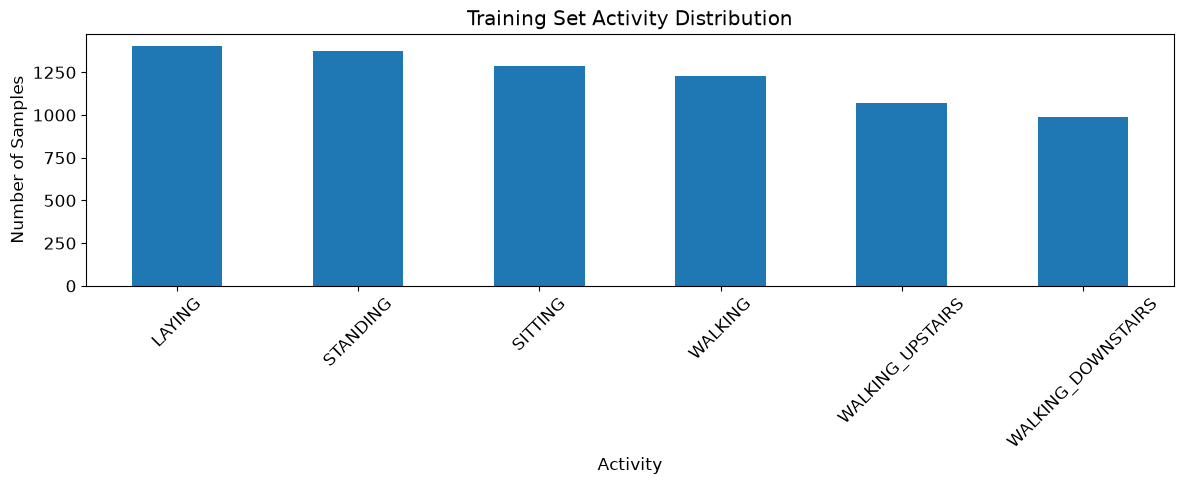

In [8]:
activity_counts.plot(kind="bar")

plt.title("Training Set Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Sensor File Names

In [9]:
SIGNAL_FILES = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

## Loader Function

In [10]:
def load_inertial_signals(data_path, split):
    """
    Load all 9 inertial signals and stack them into a single tensor.

    Parameters
    ----------
    data_path : Path
        Root dataset directory.
    split : str
        Either "train" or "test".

    Returns
    -------
    np.ndarray
        Shape: (samples, 128, 9)
    """

    signal_path = data_path / split / "Inertial Signals"

    signals = []

    for signal in SIGNAL_FILES:
        filename = signal_path / f"{signal}_{split}.txt"

        data = np.loadtxt(filename)

        signals.append(data)

    # Stack along the last axis
    return np.stack(signals, axis=-1)

## Load the Data

In [11]:
X_train = load_inertial_signals(DATASET_PATH, "train")
X_test = load_inertial_signals(DATASET_PATH, "test")

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (7352, 128, 9)
Testing Shape  : (2947, 128, 9)


## Inspect One Sample

In [12]:
sample = X_train[0]

print(sample.shape)

sample

(128, 9)


array([[ 1.808515e-04,  1.076681e-02,  5.556068e-02, ...,  1.012817e+00,
        -1.232167e-01,  1.029341e-01],
       [ 1.013856e-02,  6.579480e-03,  5.512483e-02, ...,  1.022833e+00,
        -1.268756e-01,  1.056872e-01],
       [ 9.275574e-03,  8.928878e-03,  4.840473e-02, ...,  1.022028e+00,
        -1.240037e-01,  1.021025e-01],
       ...,
       [-1.147484e-03,  1.714439e-04,  2.647864e-03, ...,  1.018445e+00,
        -1.240696e-01,  1.003852e-01],
       [-2.222655e-04,  1.574181e-03,  2.381057e-03, ...,  1.019372e+00,
        -1.227451e-01,  9.987355e-02],
       [ 1.575500e-03,  3.070189e-03, -2.269757e-03, ...,  1.021171e+00,
        -1.213260e-01,  9.498741e-02]])

## Channel Names

In [13]:
CHANNEL_NAMES = [
    "Body Acc X",
    "Body Acc Y",
    "Body Acc Z",
    "Body Gyro X",
    "Body Gyro Y",
    "Body Gyro Z",
    "Total Acc X",
    "Total Acc Y",
    "Total Acc Z",
]

## Plot One Sample

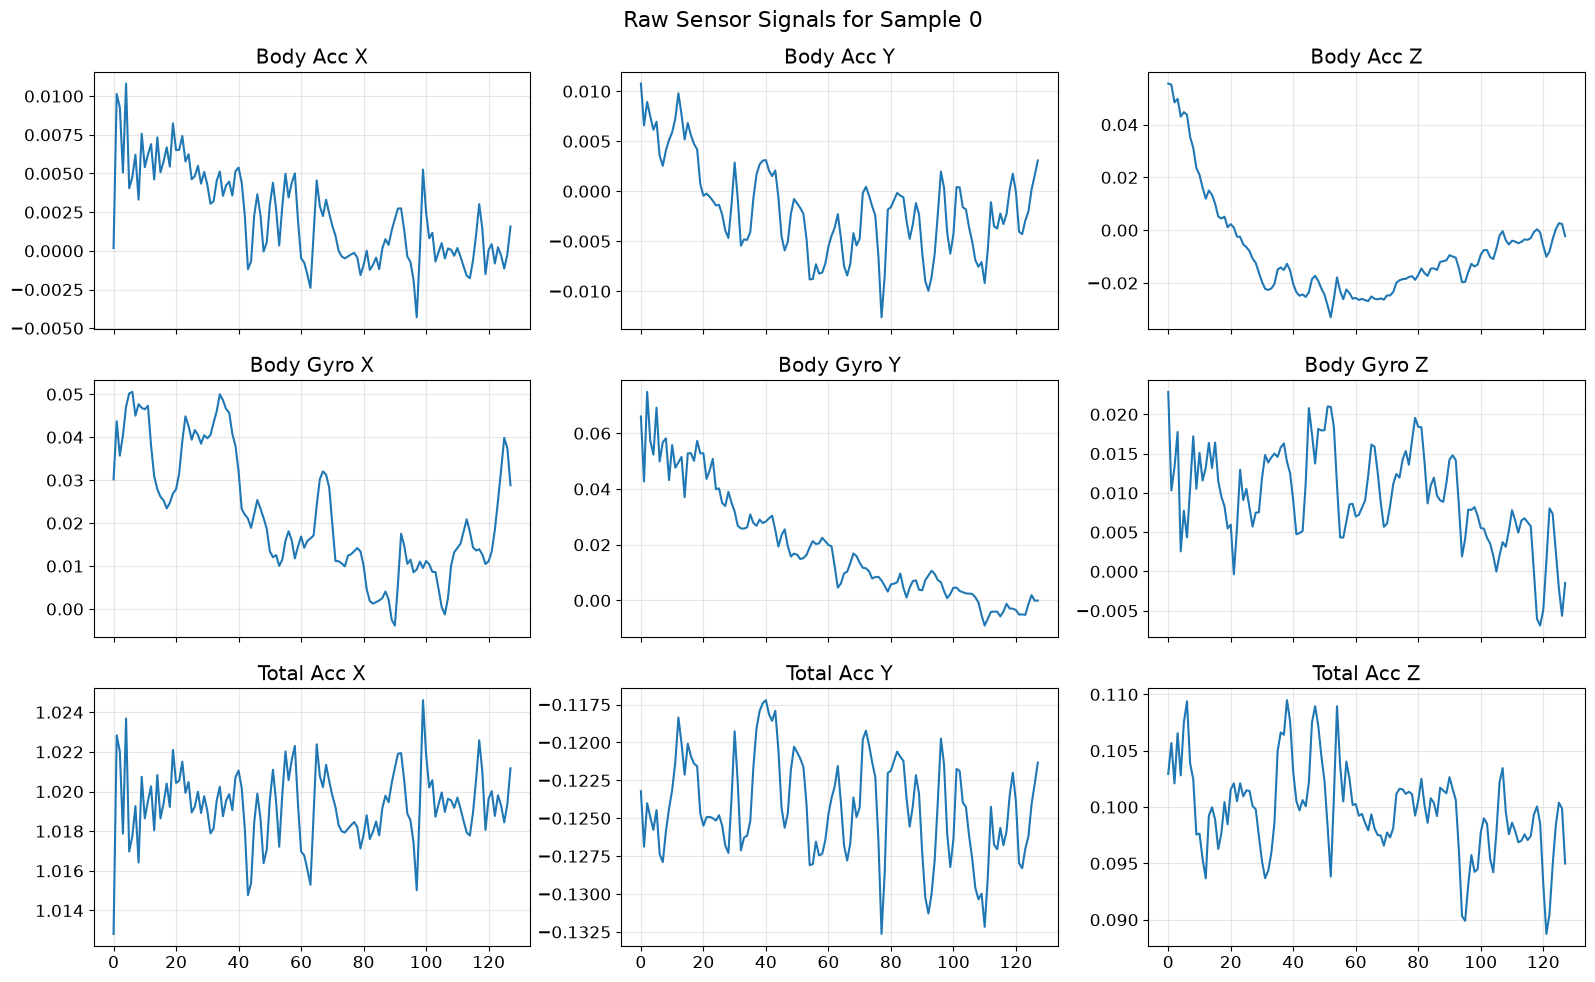

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)

sample = X_train[0]

for i, ax in enumerate(axes.flat):
    ax.plot(sample[:, i])
    ax.set_title(CHANNEL_NAMES[i])
    ax.grid(alpha=0.3)

plt.suptitle("Raw Sensor Signals for Sample 0", fontsize=16)

plt.tight_layout()
plt.show()

## Missing Values

In [17]:
print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in X_test :", np.isnan(X_test).sum())

NaNs in X_train: 0
NaNs in X_test : 0


## Value Range

In [18]:
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("Mean:", X_train.mean())
print("Std:", X_train.std())

Minimum: -5.97433
Maximum: 5.746062
Mean: 0.10206605723804434
Std: 0.4021651763827932


## Subjects

In [19]:
subject_train = pd.read_csv(
    TRAIN_PATH / "subject_train.txt",
    header=None,
    names=["Subject"]
)

subject_test = pd.read_csv(
    TEST_PATH / "subject_test.txt",
    header=None,
    names=["Subject"]
)

In [20]:
print("Training Subjects:", subject_train["Subject"].nunique())
print("Testing Subjects :", subject_test["Subject"].nunique())

print("Train IDs:", sorted(subject_train["Subject"].unique()))
print("Test IDs :", sorted(subject_test["Subject"].unique()))

Training Subjects: 21
Testing Subjects : 9
Train IDs: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
Test IDs : [np.int64(2), np.int64(4), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(18), np.int64(20), np.int64(24)]


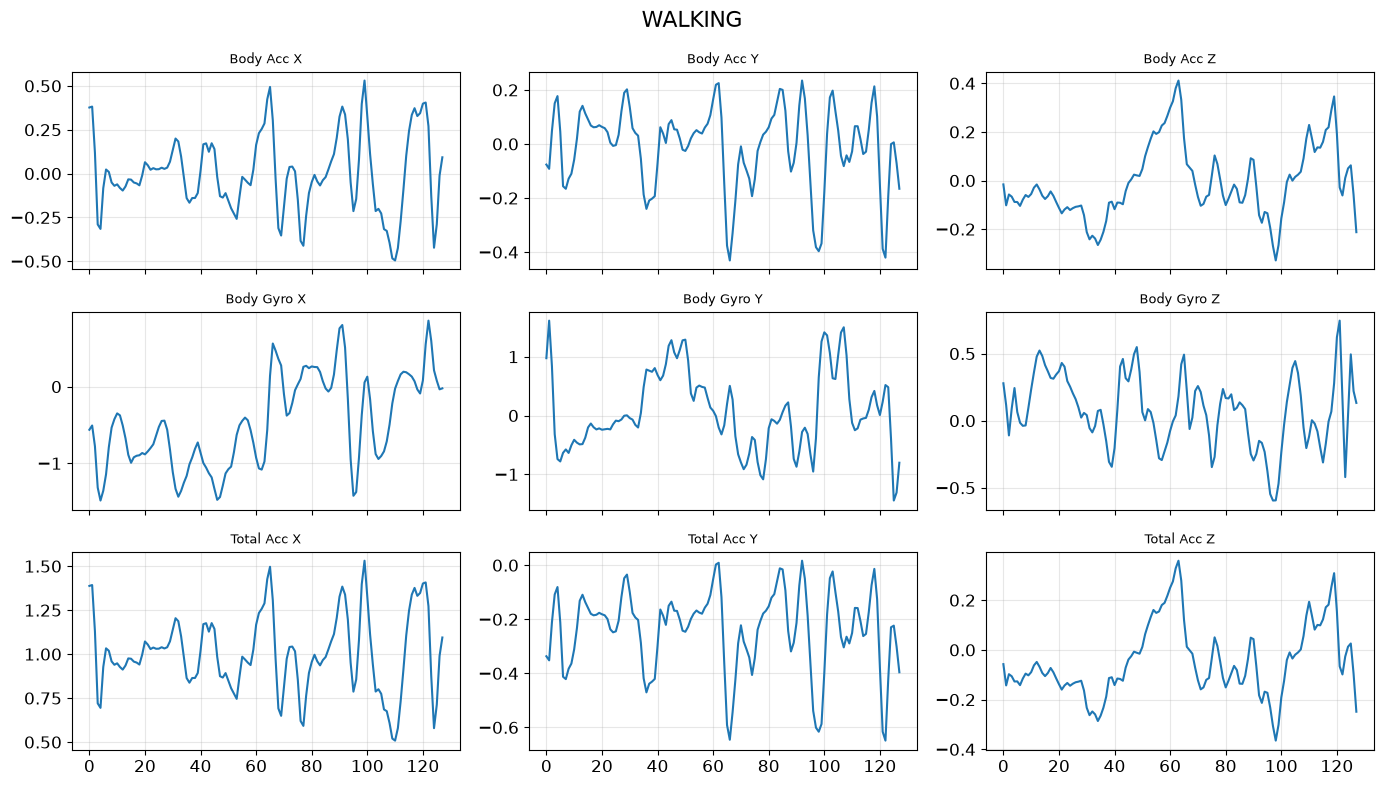

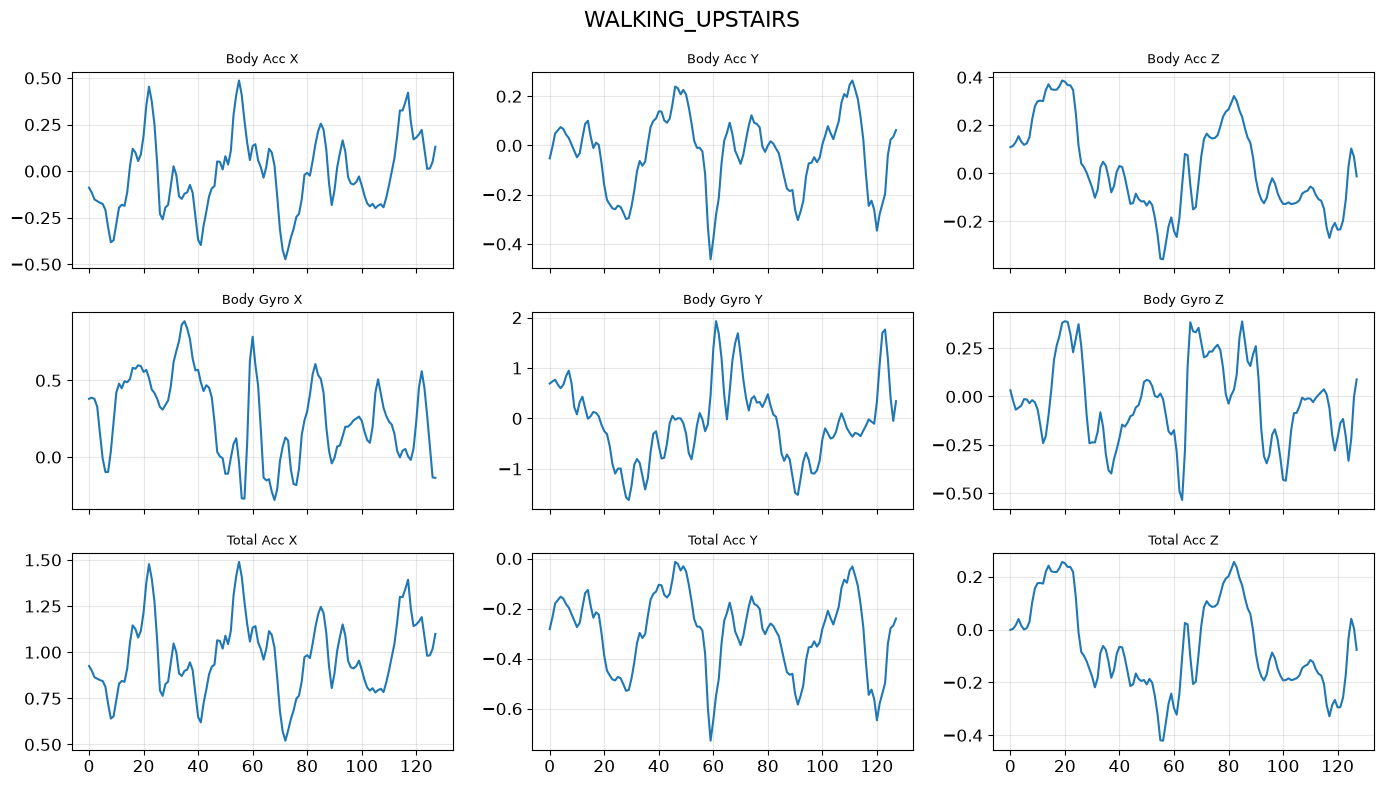

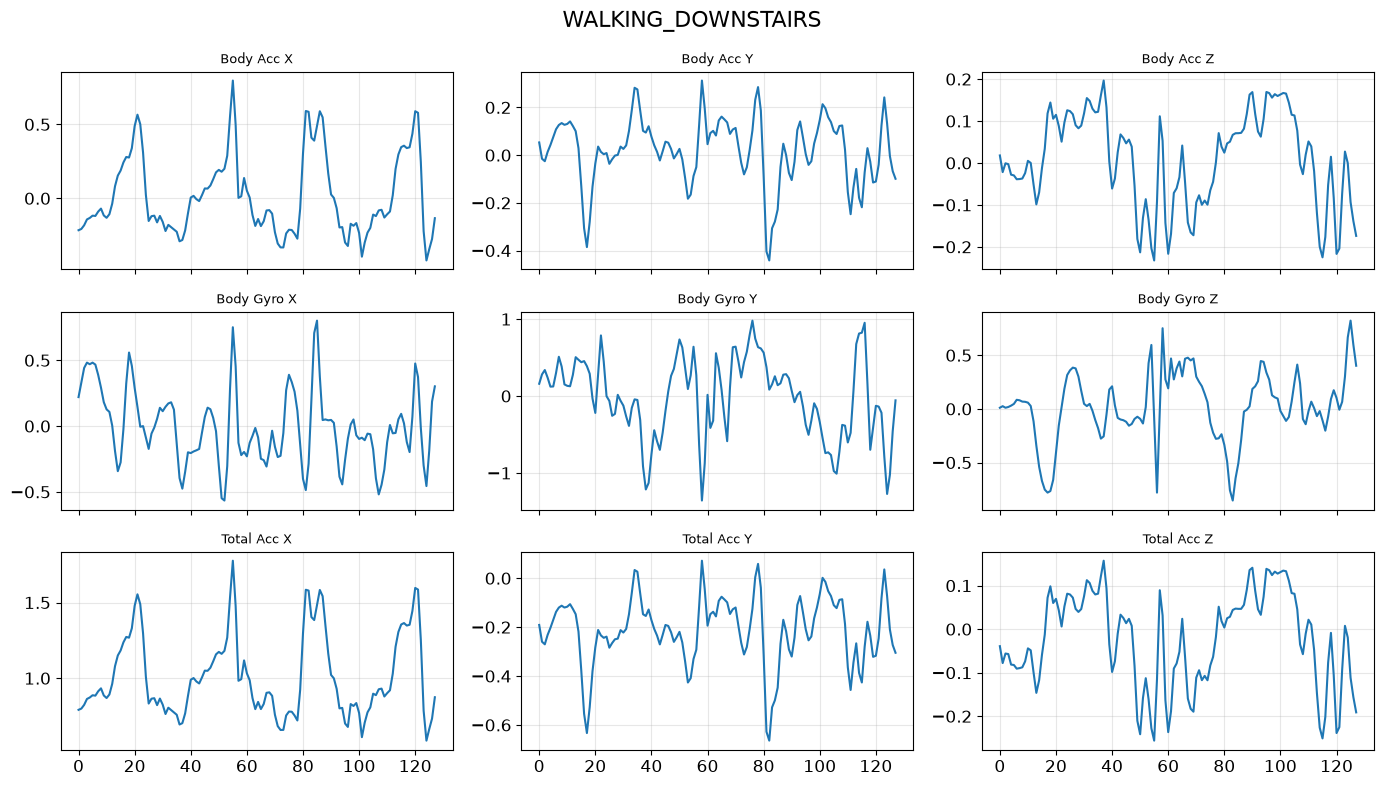

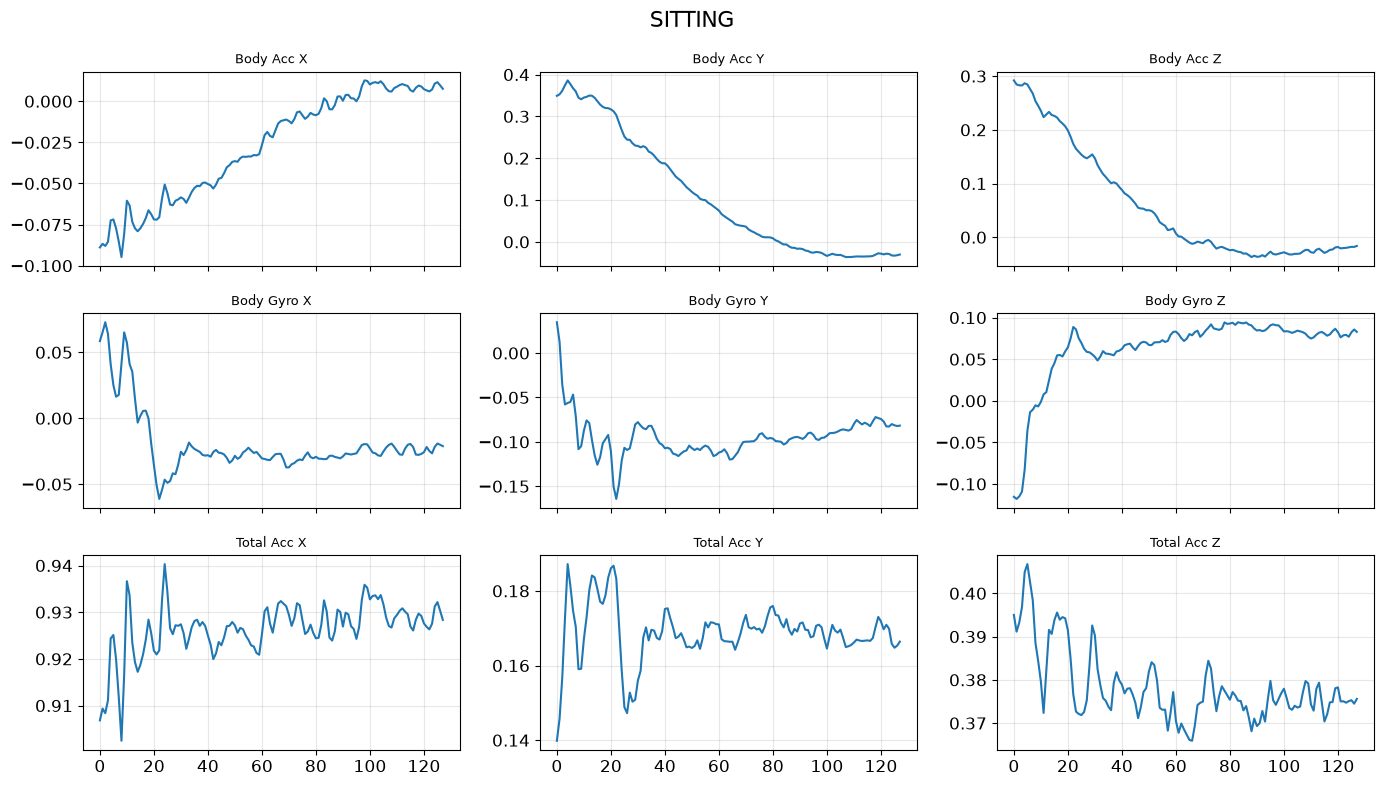

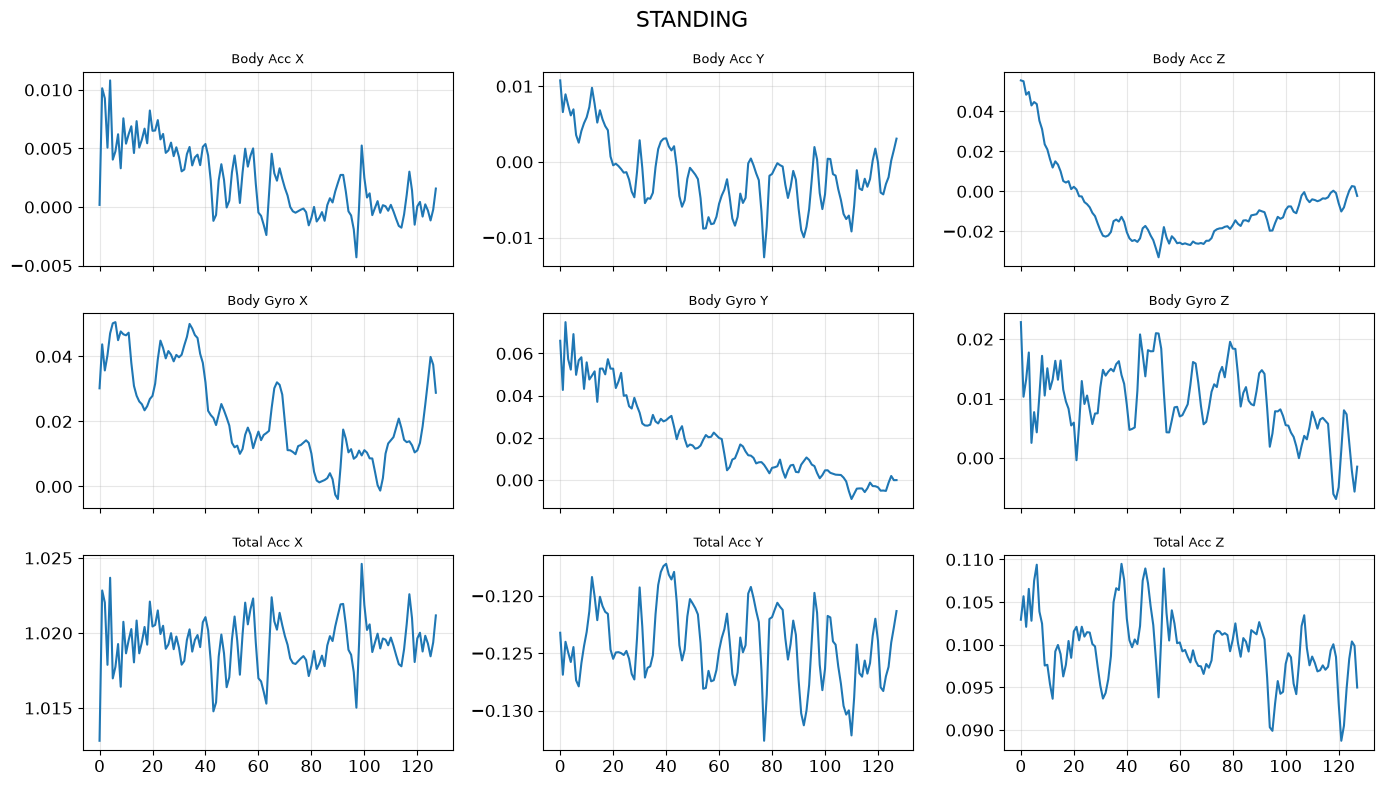

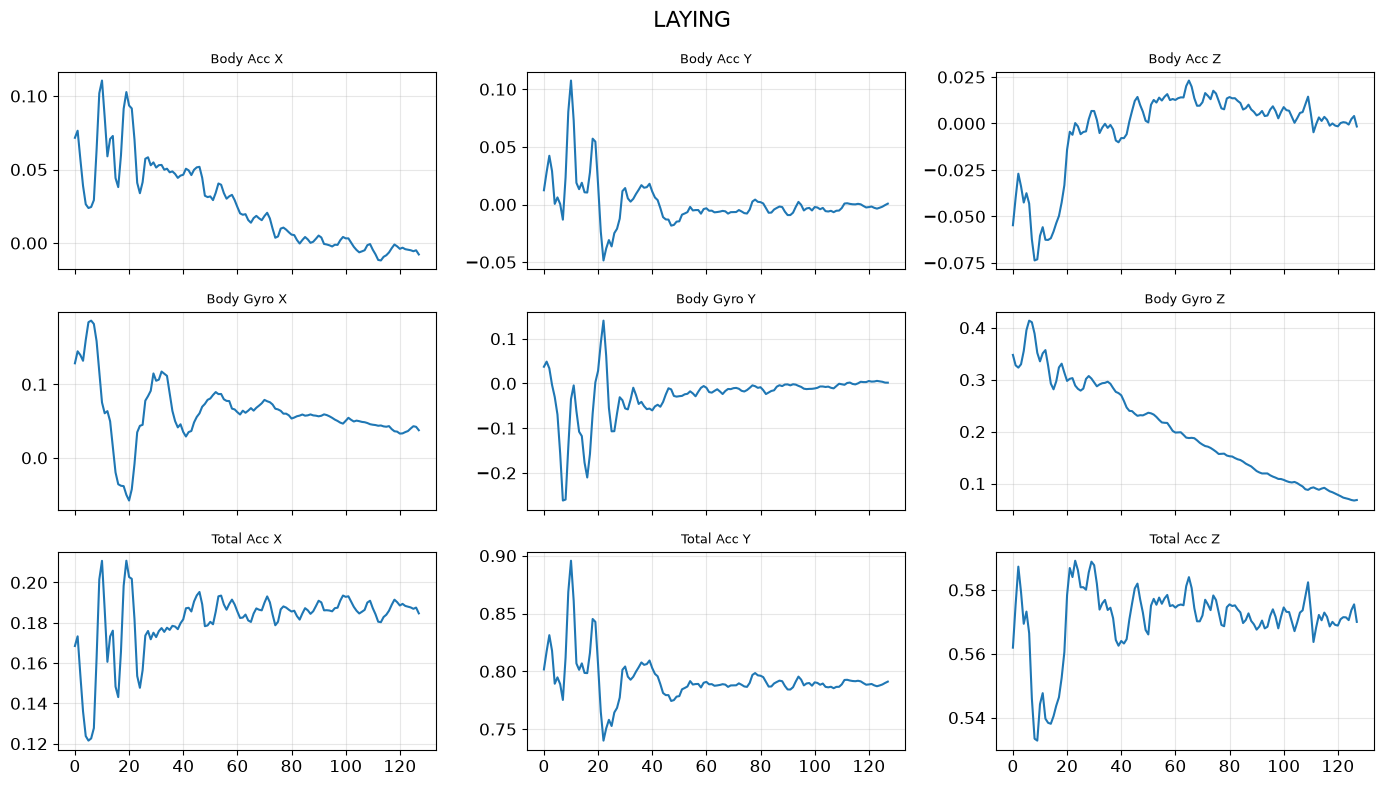

In [21]:
for activity_id, activity_name in label_map.items():

    sample_idx = y_train[y_train["ActivityID"] == activity_id].index[0]

    sample = X_train[sample_idx]

    fig, axes = plt.subplots(3, 3, figsize=(14, 8), sharex=True)

    for i, ax in enumerate(axes.flat):
        ax.plot(sample[:, i])
        ax.set_title(CHANNEL_NAMES[i], fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(activity_name, fontsize=16)

    plt.tight_layout()

    plt.show()